✅ Done | title='SONTRA SEA HOTEL'
📸 Screenshot: screenshot_sontrase.png (382 KB)


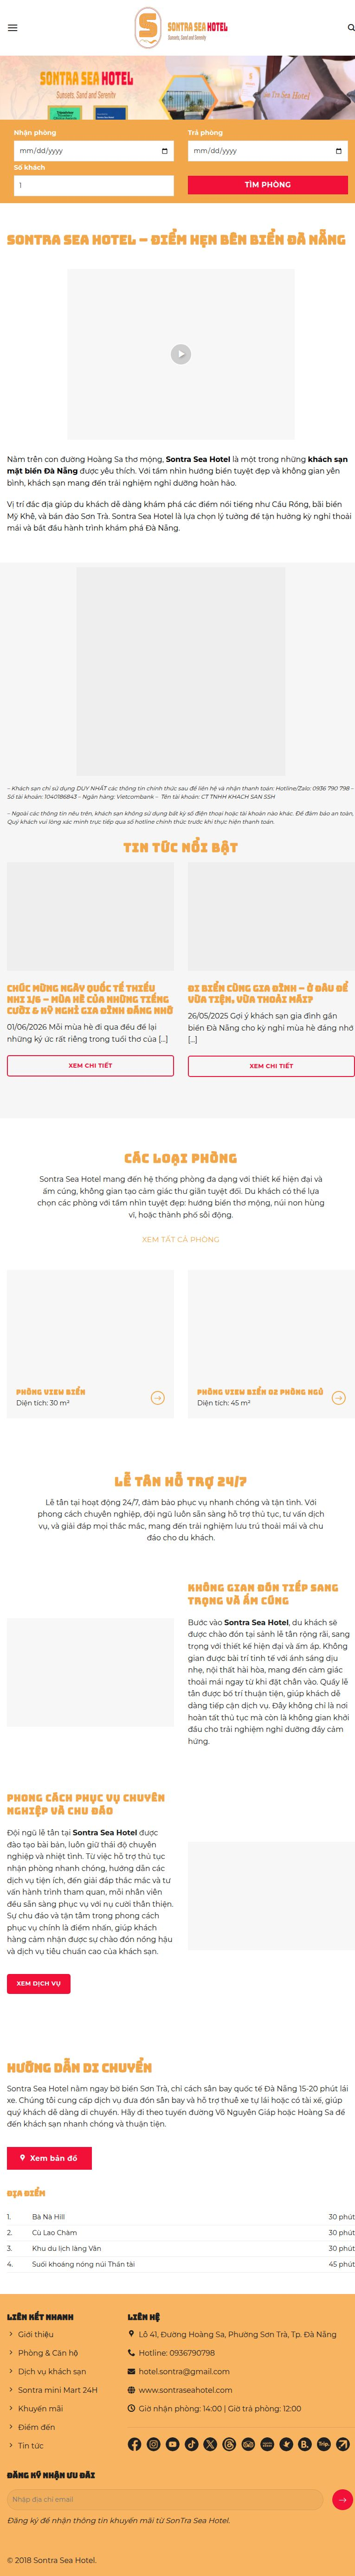

In [1]:
# ── CELL 1: nodriver — mở trang, chụp screenshot ──
import nest_asyncio
nest_asyncio.apply()
import asyncio
from pathlib import Path
from IPython.display import display, Image as IPImage

TARGET_URL = "https://sontraseahotel.com/"
SCREENSHOT_PATH = Path("screenshot_sontrase.png")

async def run_nodriver():
    import nodriver as uc
    browser = await uc.start(
        headless=True,
        browser_args=["--no-sandbox", "--disable-dev-shm-usage"],
    )
    page = await browser.get(TARGET_URL)
    await asyncio.sleep(4)

    # Scroll xuống cuối để load lazy content
    await page.evaluate("window.scrollTo(0, document.body.scrollHeight)")
    await asyncio.sleep(2)
    await page.evaluate("window.scrollTo(0, 0)")
    await asyncio.sleep(1)

    # Chụp toàn bộ trang (full page)
    await page.save_screenshot(str(SCREENSHOT_PATH), full_page=True)
    title = await page.evaluate("document.title")
    browser.stop()
    return title

title = await run_nodriver()
print(f"✅ Done | title='{title}'")
print(f"📸 Screenshot: {SCREENSHOT_PATH} ({SCREENSHOT_PATH.stat().st_size // 1024} KB)")
display(IPImage(str(SCREENSHOT_PATH), width=900))

In [7]:
import easyocr
import cv2
import time
import numpy as np
from pathlib import Path
from IPython.display import display, HTML

SCREENSHOT_PATH = Path("screenshot_sontrase.png")

# 1. Đọc ảnh
img_cv = cv2.imread(str(SCREENSHOT_PATH))
if img_cv is None:
    raise FileNotFoundError(f"Không tìm thấy file ảnh tại: {SCREENSHOT_PATH}")

H, W = img_cv.shape[:2]
print(f"Ảnh: {W}x{H} px | Chế độ: CPU Tile")

# 2. PREPROCESS
def preprocess(img):
    if W > 1440:
        scale = 1440 / W
        img = cv2.resize(img, (1440, int(H * scale)), interpolation=cv2.INTER_AREA)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)

img_cv = preprocess(img_cv)
H, W = img_cv.shape[:2]

# 3. Khởi tạo
print("Đang khởi tạo EasyOCR...")
start_time = time.time()
reader = easyocr.Reader(['vi', 'en'], gpu=False)

# 4. Tile + OCR
TILE_H = 1200
OVERLAP = 100
all_results = []

for i, y in enumerate(range(0, H, TILE_H - OVERLAP)):
    y_end = min(y + TILE_H, H)
    if y_end <= y:
        break
    
    tile = img_cv[y:y_end, 0:W]
    
    # Skip tile gần trắng
    gray = cv2.cvtColor(tile, cv2.COLOR_BGR2GRAY)
    if np.mean(gray) > 245:
        continue
    
    # OCR: detail=1 để lấy confidence, KHÔNG dùng paragraph=True
    results = reader.readtext(
        tile,
        detail=1,
        batch_size=8,
        contrast_ths=0.05,
        adjust_contrast=0.7,
    )
    
    # Filter + deduplicate overlap
    for bbox, text, conf in results:
        if conf > 0.4 and text.strip():
            center_y = (bbox[0][1] + bbox[2][1]) / 2
            if i > 0 and center_y < OVERLAP:
                continue
            all_results.append(text)
    
    print(f"  Tile {i+1}: {len(results)} đoạn")

# 5. POST-PROCESS
def fix_vietnamese(text):
    text = text.replace('@gmail com', '@gmail.com')
    text = text.replace('@yahoo com', '@yahoo.com')
    import re
    text = re.sub(r'(\d{4})(\d{3})(\d{3})', r'\1 \2 \3', text)
    text = re.sub(r'\s+', ' ', text)
    return text

all_results = [fix_vietnamese(t) for t in all_results]
FULL_OCR_TEXT = "\n\n".join(all_results)

print(f"\n⏱️ Tổng: {time.time() - start_time:.2f}s | {len(FULL_OCR_TEXT)} ký tự")

# 6. Hiển thị
html = f"""
<div style="height:500px;overflow-y:scroll;border:1px solid #10b981;padding:16px;
font-family:system-ui;font-size:14px;white-space:pre-wrap;background:#f8fafc;
line-height:1.6;color:#1e293b;">
<b style="color:#10b981;">KẾT QUẢ EASYOCR (CẢI THIỆN)</b><br><br>
{FULL_OCR_TEXT.replace('<', '&lt;').replace('>', '&gt;')}
</div>
"""
display(HTML(html))

Using CPU. Note: This module is much faster with a GPU.


Ảnh: 765x5554 px | Chế độ: CPU Tile
Đang khởi tạo EasyOCR...
  Tile 1: 18 đoạn
  Tile 2: 23 đoạn
  Tile 3: 24 đoạn
  Tile 4: 31 đoạn
  Tile 5: 39 đoạn
  Tile 6: 1 đoạn

⏱️ Tổng: 20.65s | 3104 ký tự


In [10]:
# ── CELL 2: crawl4ai — cào markdown ──
import asyncio
from crawl4ai import AsyncWebCrawler, BrowserConfig, CrawlerRunConfig
from crawl4ai.content_filter_strategy import PruningContentFilter
from crawl4ai.markdown_generation_strategy import DefaultMarkdownGenerator
from IPython.display import display, HTML

TARGET_URL = "https://sontraseahotel.com/"

async def run_crawl4ai():
    browser_cfg = BrowserConfig(
        headless=True,
        extra_args=["--no-sandbox", "--disable-dev-shm-usage"],
    )
    run_cfg = CrawlerRunConfig(
        screenshot=False,
        word_count_threshold=5,
        page_timeout=30000,
        markdown_generator=DefaultMarkdownGenerator(
            content_filter=PruningContentFilter(threshold=0.48)
        ),
    )
    async with AsyncWebCrawler(config=browser_cfg) as crawler:
        return await crawler.arun(url=TARGET_URL, config=run_cfg)

cr = await run_crawl4ai()
CRAWL_MARKDOWN = cr.markdown.fit_markdown if hasattr(cr.markdown, "fit_markdown") else str(cr.markdown)

print(f"✅ crawl4ai OK | status={cr.status_code} | {len(CRAWL_MARKDOWN)} ký tự")
print("=" * 60)
print(CRAWL_MARKDOWN)
print("=" * 60)

# Hiển thị dạng HTML scroll
html = f"""
<div style="
    height:500px; overflow-y:scroll; border:1px solid #ccc;
    padding:16px; font-family:monospace; font-size:13px;
    white-space:pre-wrap; background:#f9f9f9; line-height:1.6;
">
{CRAWL_MARKDOWN.replace('<','&lt;').replace('>','&gt;')}
</div>
"""
display(HTML(f"<b>📄 Markdown — {len(CRAWL_MARKDOWN)} ký tự</b>" + html))

[INIT].... → Crawl4AI 0.8.7 

[FETCH]... ↓ https://sontraseahotel.com/                                                                          | ✓ | ⏱: 5.18s 

[SCRAPE].. ◆ https://sontraseahotel.com/                                                                          | ✓ | ⏱: 0.14s 

[COMPLETE] ● https://sontraseahotel.com/                                                                          | ✓ | ⏱: 5.34s 

✅ crawl4ai OK | status=200 | 5973 ký tự
[Skip to content](https://sontraseahotel.com/#main)
# SONTRA SEA HOTEL – ĐIỂM HẸN BÊN BIỂN ĐÀ NẴNG
Nằm trên con đường Hoàng Sa thơ mộng, **Sontra Sea Hotel** là một trong những **khách sạn mặt biển Đà Nẵng** được yêu thích. Với tầm nhìn hướng biển tuyệt đẹp và không gian yên bình, khách sạn mang đến trải nghiệm nghỉ dưỡng hoàn hảo.
Vị trí đắc địa giúp du khách dễ dàng khám phá các điểm nổi tiếng như Cầu Rồng, bãi biển Mỹ Khê, và bán đảo Sơn Trà. Sontra Sea Hotel là lựa chọn lý tưởng để tận hưởng kỳ nghỉ thoải mái và bắt đầu hành trình khám phá Đà Nẵng.
_– Khách sạn chỉ sử dụng DUY NHẤT các thông tin chính thức sau để liên hệ và nhận thanh toán: Hotline/Zalo: 0936 790 798 – Số tài khoản: 1040186843 – Ngân hàng: Vietcombank – Tên tài khoản: CT TNHH KHACH SAN SSH_
_– Ngoài các thông tin nêu trên, khách sạn không sử dụng bất kỳ số điện thoại hoặc tài khoản nào khác. Để đảm bảo an toàn, Quý khách vui lòng xác minh trực tiếp qua số hotline chính thức t